In [26]:
import subprocess
import sys

def install(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    except:
        pass

packages = ["imbalanced-learn", "xgboost", "catboost", "openpyxl", "scipy"]
for pkg in packages:
    install(pkg)

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, PowerTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from scipy.stats import skew
from sklearn.utils.class_weight import compute_class_weight

In [28]:
INPUT_PATH = "/content/Transformed_Dataset.xlsx"
TIME_COL = "MonthYear"
TARGET_COL = "PatientVisits_Sum"
AGE_COL = "AgeGroup"
GENDER_COL = "Gender"
DRUG_COL = "DrugName"
COMPANY_COL = "CompanyName"
TYPE_COL = "type"
SPEC_COL = "Category_Grouped"

COVID_CUTOFF_DATE = "2021-01-01"
TOP_PERCENTILE = 75
RANDOM_STATE = 42

OPTIMAL_THRESHOLD = 0.35
CLASS_WEIGHT_MULTIPLIER = 5.0

np.random.seed(RANDOM_STATE)


In [29]:
df_raw = pd.read_excel(INPUT_PATH)
df_raw.columns = df_raw.columns.str.strip()

def clean_text(s):
    return s.astype(str).str.strip().str.title().str.replace(r'\s+', ' ', regex=True)

for col in [DRUG_COL, COMPANY_COL, TYPE_COL, AGE_COL, GENDER_COL, SPEC_COL]:
    if col in df_raw.columns:
        df_raw[col] = clean_text(df_raw[col])

df_raw["MonthYear_dt"] = pd.to_datetime(df_raw[TIME_COL], errors="coerce")
df_raw = df_raw[~df_raw["MonthYear_dt"].isna()].copy()
df_raw[TARGET_COL] = pd.to_numeric(df_raw[TARGET_COL], errors="coerce")
df_raw = df_raw[~df_raw[TARGET_COL].isna()].copy()
df_raw = df_raw[df_raw[TARGET_COL] > 0].copy()

df = df_raw[df_raw['MonthYear_dt'] >= COVID_CUTOFF_DATE].copy()

print(f"Total records: {len(df):,}")
print(f"Date range: {df['MonthYear_dt'].min().date()} to {df['MonthYear_dt'].max().date()}")
print(f"Unique drugs: {df[DRUG_COL].nunique()}")
print(f"Unique companies: {df[COMPANY_COL].nunique()}")
print(f"Unique specializations: {df[SPEC_COL].nunique()}")

Total records: 86,765
Date range: 2021-01-01 to 2025-07-01
Unique drugs: 140
Unique companies: 160
Unique specializations: 4


In [30]:
df_agg = df.groupby([DRUG_COL, COMPANY_COL, SPEC_COL, AGE_COL, GENDER_COL, TYPE_COL]).agg({
    TARGET_COL: 'sum'
}).reset_index()

df_agg.columns = [DRUG_COL, COMPANY_COL, SPEC_COL, AGE_COL, GENDER_COL, TYPE_COL, 'Total_Volume']

In [31]:
drug_breadth = df_agg.groupby(DRUG_COL).agg({
    SPEC_COL: 'nunique',
    AGE_COL: 'nunique',
    GENDER_COL: 'nunique'
}).reset_index()
drug_breadth.columns = [DRUG_COL, 'Drug_Num_Specializations', 'Drug_Num_AgeGroups', 'Drug_Num_Genders']

company_portfolio = df_agg.groupby(COMPANY_COL)[DRUG_COL].nunique().reset_index()
company_portfolio.columns = [COMPANY_COL, 'Company_Portfolio_Size']

market_structure = df_agg.groupby(SPEC_COL).agg({
    DRUG_COL: 'nunique',
    COMPANY_COL: 'nunique'
}).reset_index()
market_structure.columns = [SPEC_COL, 'Market_Num_Drugs', 'Market_Num_Companies']

df_model = df_agg.copy()
df_model = df_model.merge(drug_breadth, on=DRUG_COL, how='left')
df_model = df_model.merge(company_portfolio, on=COMPANY_COL, how='left')
df_model = df_model.merge(market_structure, on=SPEC_COL, how='left')

df_model['Market_Competition_Index'] = df_model['Market_Num_Drugs'] * df_model['Market_Num_Companies']
df_model['Drug_Market_Breadth'] = df_model['Drug_Num_Specializations'] * df_model['Drug_Num_AgeGroups']
df_model['Drug_Presence_Score'] = (
    df_model['Drug_Num_Specializations'] +
    df_model['Drug_Num_AgeGroups'] +
    df_model['Drug_Num_Genders']
)

In [32]:
NUMERICAL_FEATURES = [
    'Drug_Num_Specializations',
    'Drug_Num_AgeGroups',
    'Drug_Num_Genders',
    'Company_Portfolio_Size',
    'Market_Num_Drugs',
    'Market_Num_Companies',
    'Market_Competition_Index',
    'Drug_Market_Breadth',
    'Drug_Presence_Score'
]

CATEGORICAL_FEATURES = [SPEC_COL, AGE_COL, GENDER_COL, TYPE_COL]

for col in NUMERICAL_FEATURES:
    df_model[col] = df_model[col].fillna(0)

df_model['Volume_Percentile_Target'] = df_model.groupby([SPEC_COL])['Total_Volume'].rank(pct=True)
df_model['Target'] = (df_model['Volume_Percentile_Target'] >= (TOP_PERCENTILE/100)).astype(int)


In [33]:
print(f"Numerical features: {len(NUMERICAL_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"TOTAL FEATURES: {len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES)}")
print(f"\nWinners: {df_model['Target'].sum():,} ({100*df_model['Target'].mean():.1f}%)")
print(f"Non-Winners: {(df_model['Target']==0).sum():,} ({100*(1-df_model['Target'].mean()):.1f}%)")

Numerical features: 9
Categorical features: 4
TOTAL FEATURES: 13

Winners: 1,414 (25.0%)
Non-Winners: 4,231 (75.0%)


In [34]:
X_full = df_model[CATEGORICAL_FEATURES + NUMERICAL_FEATURES].copy()
y = df_model['Target'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Total: {len(y):,} samples")
print(f"Train: {len(y_train):,} samples ({100*len(y_train)/len(y):.0f}%)")
print(f"Test: {len(y_test):,} samples ({100*len(y_test)/len(y):.0f}%)")

print(f"Train - Winners: {y_train.sum():,} ({100*y_train.mean():.1f}%), Non-Winners: {(y_train==0).sum():,}")
print(f"Test - Winners: {y_test.sum():,} ({100*y_test.mean():.1f}%), Non-Winners: {(y_test==0).sum():,}")
print(f"Imbalance Ratio: {(y_train==0).sum() / (y_train==1).sum():.2f}:1")

Total: 5,645 samples
Train: 4,516 samples (80%)
Test: 1,129 samples (20%)
Train - Winners: 1,131 (25.0%), Non-Winners: 3,385
Test - Winners: 283 (25.1%), Non-Winners: 846
Imbalance Ratio: 2.99:1


In [35]:
label_encoders = {}
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    X_test[col] = X_test[col].replace(-1, X_train[col].mode()[0])
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} unique values")


Category_Grouped: 4 unique values
AgeGroup: 6 unique values
Gender: 3 unique values
type: 4 unique values


In [36]:
skew_analysis = []
for col in NUMERICAL_FEATURES:
    skewness = skew(X_train[col])
    skew_analysis.append({'Feature': col, 'Skewness': skewness})

skew_df = pd.DataFrame(skew_analysis)
skewed_features = skew_df[abs(skew_df['Skewness']) > 1]['Feature'].tolist()

power_transformer = None
if len(skewed_features) > 0:
    print(f"\n Applying PowerTransformer to {len(skewed_features)} skewed features...")
    power_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
    X_train[skewed_features] = power_transformer.fit_transform(X_train[skewed_features])
    X_test[skewed_features] = power_transformer.transform(X_test[skewed_features])



 Applying PowerTransformer to 5 skewed features...


In [37]:
print(f"\n Scaling {len(NUMERICAL_FEATURES)} numerical features with RobustScaler...")
scaler = RobustScaler()
X_train[NUMERICAL_FEATURES] = scaler.fit_transform(X_train[NUMERICAL_FEATURES])
X_test[NUMERICAL_FEATURES] = scaler.transform(X_test[NUMERICAL_FEATURES])


 Scaling 9 numerical features with RobustScaler...


In [38]:
print(f"Total: {len(y_train):,} samples")
print(f"Winners: {y_train.sum():,} ({100*y_train.mean():.1f}%)")
print(f"Non-Winners: {(y_train==0).sum():,} ({100*(1-y_train.mean()):.1f}%)")

smote = SMOTE(
    sampling_strategy=1.0,
    random_state=RANDOM_STATE,
    k_neighbors=5
)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Total: {len(y_train_balanced):,} samples")
print(f"Winners: {y_train_balanced.sum():,} ({100*y_train_balanced.mean():.1f}%)")
print(f"Non-Winners: {(y_train_balanced==0).sum():,} ({100*(1-y_train_balanced.mean()):.1f}%)")

Total: 4,516 samples
Winners: 1,131 (25.0%)
Non-Winners: 3,385 (75.0%)
Total: 6,770 samples
Winners: 3,385 (50.0%)
Non-Winners: 3,385 (50.0%)


In [39]:
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {
    0: class_weights_array[0],
    1: class_weights_array[1] * CLASS_WEIGHT_MULTIPLIER
}

print(f"Non-Winner (0): {class_weights_dict[0]:.2f}")
print(f"Winner (1): {class_weights_dict[1]:.2f}")

Non-Winner (0): 0.67
Winner (1): 9.98


In [40]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=2,
        class_weight=class_weights_dict,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        scale_pos_weight=class_weights_dict[1],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=6,
        class_weights=[class_weights_dict[0], class_weights_dict[1]],
        random_state=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False
    )
}

print(f"4 models defined with {len(NUMERICAL_FEATURES)} numerical + {len(CATEGORICAL_FEATURES)} categorical features")

4 models defined with 9 numerical + 4 categorical features


In [41]:
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = []

for name, model in models.items():
    print(f"\n[CV] {name}...")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_validate(model, X_train_balanced, y_train_balanced,
                               cv=skf, scoring=scoring_metrics, n_jobs=-1)

    cv_results.append({
        'Model': name,
        'CV_Accuracy': cv_scores['test_accuracy'].mean(),
        'CV_Precision': cv_scores['test_precision'].mean(),
        'CV_Recall': cv_scores['test_recall'].mean(),
        'CV_F1': cv_scores['test_f1'].mean(),
        'CV_AUC': cv_scores['test_roc_auc'].mean()
    })

    print(f"Accuracy: {cv_scores['test_accuracy'].mean():.4f}")
    print(f"Precision: {cv_scores['test_precision'].mean():.4f}")
    print(f"Recall: {cv_scores['test_recall'].mean():.4f}")
    print(f"F1-Score: {cv_scores['test_f1'].mean():.4f}")
    print(f"AUC-ROC: {cv_scores['test_roc_auc'].mean():.4f}")

cv_df = pd.DataFrame(cv_results)
print("\n", cv_df.to_string(index=False))


[CV] Random Forest...
Accuracy: 0.7923
Precision: 0.7122
Recall: 0.9820
F1-Score: 0.8255
AUC-ROC: 0.9162

[CV] Gradient Boosting...
Accuracy: 0.8539
Precision: 0.8406
Recall: 0.8742
F1-Score: 0.8568
AUC-ROC: 0.9402

[CV] XGBoost...
Accuracy: 0.8108
Precision: 0.7302
Recall: 0.9870
F1-Score: 0.8393
AUC-ROC: 0.9351

[CV] CatBoost...
Accuracy: 0.7328
Precision: 0.6531
Recall: 0.9938
F1-Score: 0.7882
AUC-ROC: 0.9133

             Model  CV_Accuracy  CV_Precision  CV_Recall    CV_F1   CV_AUC
    Random Forest     0.792319      0.712238   0.981979 0.825540 0.916177
Gradient Boosting     0.853914      0.840571   0.874151 0.856800 0.940184
          XGBoost     0.810783      0.730197   0.987001 0.839276 0.935069
         CatBoost     0.732792      0.653113   0.993796 0.788170 0.913251


In [42]:
fitted_models = {}

for name, model in models.items():
    print(f"  Training {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    fitted_models[name] = model


  Training Random Forest...
  Training Gradient Boosting...
  Training XGBoost...
  Training CatBoost...


In [43]:
test_results_default = []
test_results_optimized = []

for name, model in fitted_models.items():

    y_proba = model.predict_proba(X_test)[:, 1]

    y_pred_default = model.predict(X_test)
    cm_default = confusion_matrix(y_test, y_pred_default)
    tn, fp, fn, tp = cm_default.ravel()

    test_results_default.append({
        'Model': name,
        'Threshold': 0.5,
        'Test_Accuracy': accuracy_score(y_test, y_pred_default),
        'Precision': precision_score(y_test, y_pred_default),
        'Recall': recall_score(y_test, y_pred_default),
        'F1-Score': f1_score(y_test, y_pred_default),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'True_Positives': tp,
        'True_Negatives': tn,
        'False_Positives': fp,
        'False_Negatives': fn
    })

    print(f"\nDefault Threshold (0.5):")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred_default):.4f} ({accuracy_score(y_test, y_pred_default)*100:.2f}%)")
    print(f"Recall: {recall_score(y_test, y_pred_default):.4f} ({recall_score(y_test, y_pred_default)*100:.2f}%)")
    print(f"Precision: {precision_score(y_test, y_pred_default):.4f} ({precision_score(y_test, y_pred_default)*100:.2f}%)")
    print(f"F1-Score: {f1_score(y_test, y_pred_default):.4f}")
    print(f"False Negatives: {fn}")

    y_pred_opt = (y_proba >= OPTIMAL_THRESHOLD).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm_opt.ravel()

    test_results_optimized.append({
        'Model': name,
        'Threshold': OPTIMAL_THRESHOLD,
        'Test_Accuracy': accuracy_score(y_test, y_pred_opt),
        'Precision': precision_score(y_test, y_pred_opt),
        'Recall': recall_score(y_test, y_pred_opt),
        'F1-Score': f1_score(y_test, y_pred_opt),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'True_Positives': tp,
        'True_Negatives': tn,
        'False_Positives': fp,
        'False_Negatives': fn
    })

    print(f"Test Accuracy: {accuracy_score(y_test, y_pred_opt):.4f} ({accuracy_score(y_test, y_pred_opt)*100:.2f}%)")
    print(f"Recall: {recall_score(y_test, y_pred_opt):.4f} ({recall_score(y_test, y_pred_opt)*100:.2f}%)")
    print(f"Precision: {precision_score(y_test, y_pred_opt):.4f} ({precision_score(y_test, y_pred_opt)*100:.2f}%)")
    print(f"F1-Score: {f1_score(y_test, y_pred_opt):.4f}")
    print(f"False Negatives: {fn}")

test_default_df = pd.DataFrame(test_results_default)
test_optimized_df = pd.DataFrame(test_results_optimized)


Default Threshold (0.5):
Test Accuracy: 0.6794 (67.94%)
Recall: 0.9293 (92.93%)
Precision: 0.4347 (43.47%)
F1-Score: 0.5923
False Negatives: 20
Test Accuracy: 0.6377 (63.77%)
Recall: 0.9647 (96.47%)
Precision: 0.4062 (40.62%)
F1-Score: 0.5717
False Negatives: 10

Default Threshold (0.5):
Test Accuracy: 0.8060 (80.60%)
Recall: 0.7173 (71.73%)
Precision: 0.5936 (59.36%)
F1-Score: 0.6496
False Negatives: 80
Test Accuracy: 0.7706 (77.06%)
Recall: 0.8516 (85.16%)
Precision: 0.5262 (52.62%)
F1-Score: 0.6505
False Negatives: 42

Default Threshold (0.5):
Test Accuracy: 0.7015 (70.15%)
Recall: 0.9541 (95.41%)
Precision: 0.4545 (45.45%)
F1-Score: 0.6157
False Negatives: 13
Test Accuracy: 0.6590 (65.90%)
Recall: 0.9717 (97.17%)
Precision: 0.4218 (42.18%)
F1-Score: 0.5882
False Negatives: 8

Default Threshold (0.5):
Test Accuracy: 0.5988 (59.88%)
Recall: 0.9859 (98.59%)
Precision: 0.3832 (38.32%)
F1-Score: 0.5519
False Negatives: 4
Test Accuracy: 0.5527 (55.27%)
Recall: 0.9894 (98.94%)
Precision:

In [44]:
print(test_default_df[['Model', 'Test_Accuracy', 'Recall', 'Precision', 'F1-Score', 'False_Negatives', 'False_Positives']].to_string(index=False))
print(test_optimized_df[['Model', 'Test_Accuracy', 'Recall', 'Precision', 'F1-Score', 'False_Negatives', 'False_Positives']].to_string(index=False))

best_model_name = test_optimized_df.loc[test_optimized_df['Recall'].idxmax(), 'Model']
best_model_metrics = test_optimized_df[test_optimized_df['Model'] == best_model_name].iloc[0]
default_metrics = test_default_df[test_default_df['Model'] == best_model_name].iloc[0]


print(f"\n BEST MODEL: {best_model_name}")

print(f"Test Accuracy: {best_model_metrics['Test_Accuracy']:.4f} ({best_model_metrics['Test_Accuracy']*100:.2f}%)")
print(f"Recall: {best_model_metrics['Recall']:.4f} ({best_model_metrics['Recall']*100:.2f}%)")
print(f"Precision: {best_model_metrics['Precision']:.4f} ({best_model_metrics['Precision']*100:.2f}%)")
print(f"F1-Score: {best_model_metrics['F1-Score']:.4f}")
print(f"AUC-ROC: {best_model_metrics['AUC-ROC']:.4f}")
print(f"False Negatives: {int(best_model_metrics['False_Negatives'])} (missed winners)")
print(f"False Positives: {int(best_model_metrics['False_Positives'])} (extra investigations)")

print(f"\nDefault Threshold (0.5) Performance:")
print(f"Test Accuracy: {default_metrics['Test_Accuracy']:.4f} ({default_metrics['Test_Accuracy']*100:.2f}%)")
print(f"Recall: {default_metrics['Recall']:.4f} ({default_metrics['Recall']*100:.2f}%)")
print(f"False Negatives: {int(default_metrics['False_Negatives'])}")

fn_improvement = int(default_metrics['False_Negatives']) - int(best_model_metrics['False_Negatives'])
recall_improvement = best_model_metrics['Recall'] - default_metrics['Recall']
print(f"False Negatives: {int(default_metrics['False_Negatives'])} → {int(best_model_metrics['False_Negatives'])} (reduced by {fn_improvement})")
print(f"Recall: {default_metrics['Recall']:.4f} → {best_model_metrics['Recall']:.4f} (improved by {recall_improvement:.4f})")

            Model  Test_Accuracy   Recall  Precision  F1-Score  False_Negatives  False_Positives
    Random Forest       0.679362 0.929329   0.434711  0.592342               20              342
Gradient Boosting       0.806023 0.717314   0.593567  0.649600               80              139
          XGBoost       0.701506 0.954064   0.454545  0.615735               13              324
         CatBoost       0.598760 0.985866   0.383242  0.551929                4              449
            Model  Test_Accuracy   Recall  Precision  F1-Score  False_Negatives  False_Positives
    Random Forest       0.637733 0.964664   0.406250  0.571728               10              399
Gradient Boosting       0.770593 0.851590   0.526201  0.650472               42              217
          XGBoost       0.658990 0.971731   0.421779  0.588235                8              377
         CatBoost       0.552702 0.989399   0.358056  0.525822                3              502

 BEST MODEL: CatBoost
Test Ac

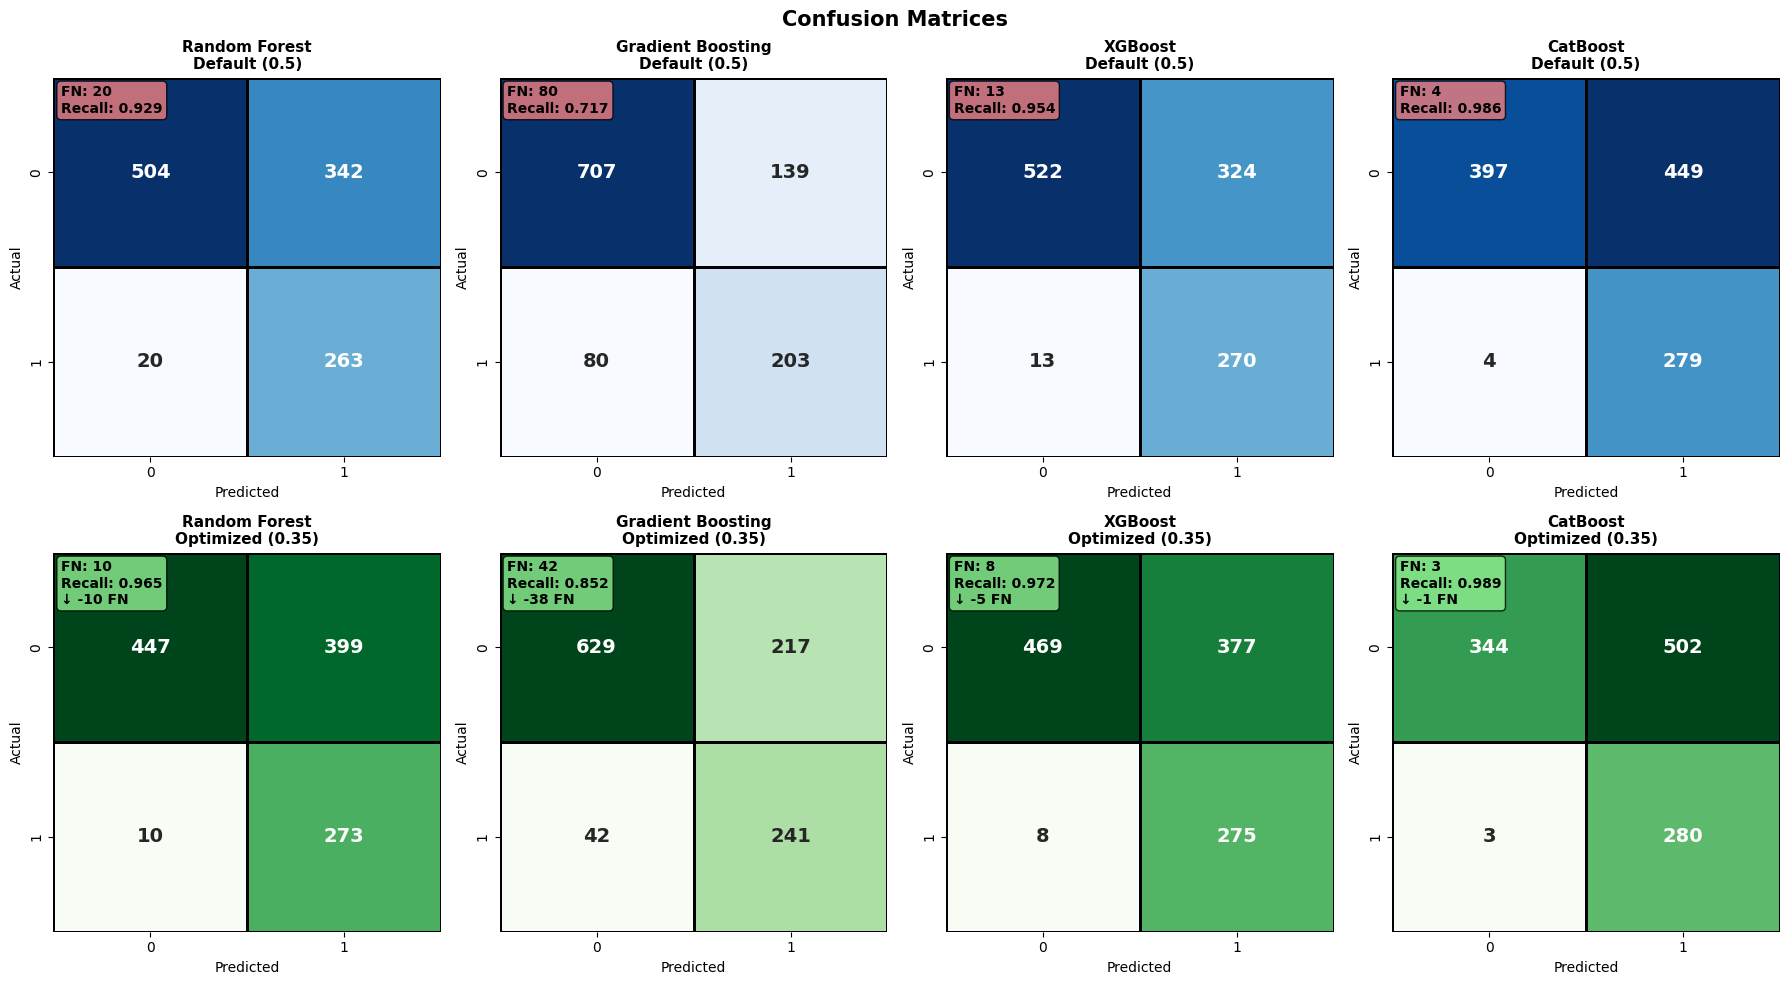

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for idx, name in enumerate(fitted_models.keys()):
    ax = axes[0, idx]
    default_row = test_default_df[test_default_df['Model'] == name].iloc[0]
    cm_default = np.array([[default_row['True_Negatives'], default_row['False_Positives']],
                           [default_row['False_Negatives'], default_row['True_Positives']]])

    sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2, linecolor='black')
    ax.set_title(f'{name}\nDefault (0.5)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

    fn = int(default_row['False_Negatives'])
    recall = default_row['Recall']
    ax.text(0.02, 0.98, f'FN: {fn}\nRecall: {recall:.3f}',
           transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

    ax = axes[1, idx]
    opt_row = test_optimized_df[test_optimized_df['Model'] == name].iloc[0]
    cm_opt = np.array([[opt_row['True_Negatives'], opt_row['False_Positives']],
                       [opt_row['False_Negatives'], opt_row['True_Positives']]])

    sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax,
                annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2, linecolor='black')
    ax.set_title(f'{name}\nOptimized ({OPTIMAL_THRESHOLD})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

    fn = int(opt_row['False_Negatives'])
    recall = opt_row['Recall']
    fn_reduction = int(default_row['False_Negatives']) - fn
    ax.text(0.02, 0.98, f'FN: {fn}\nRecall: {recall:.3f}\n↓ -{fn_reduction} FN',
           transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


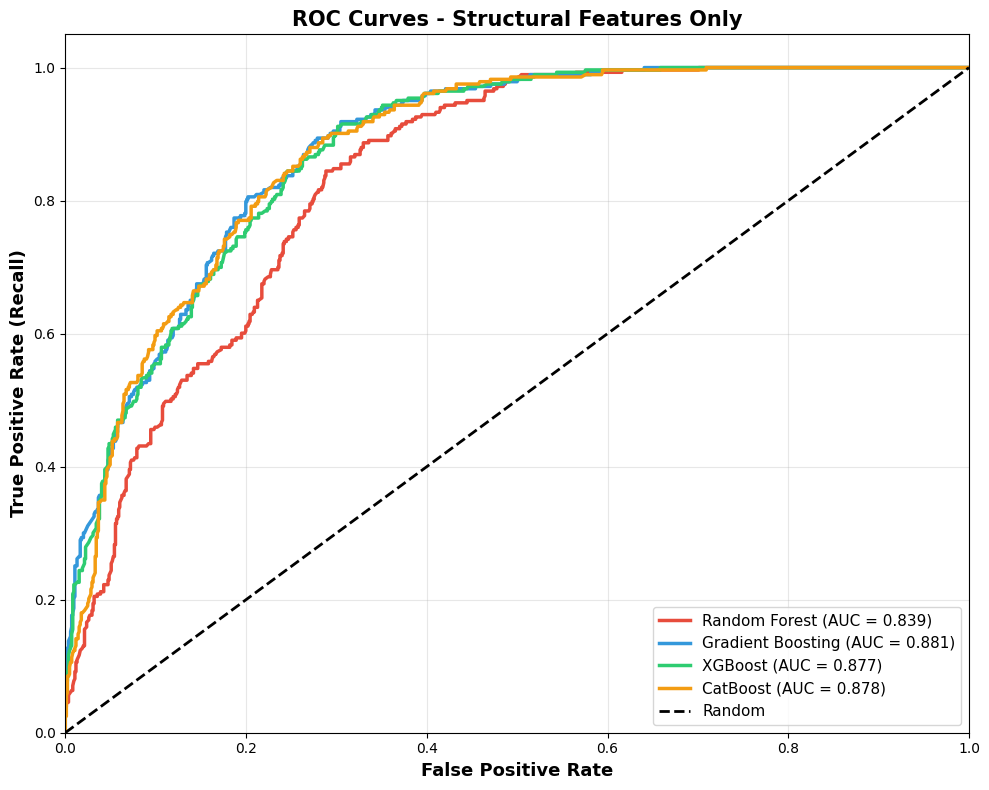

In [46]:
plt.figure(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (name, model) in enumerate(fitted_models.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[idx], linewidth=2.5,
            label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=13, fontweight='bold')
plt.title('ROC Curves - Structural Features Only', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                 Feature  Importance
  Company_Portfolio_Size   32.997325
                    type   19.545014
     Drug_Presence_Score   10.047694
        Drug_Num_Genders    9.888336
                AgeGroup    5.079226
                  Gender    4.434685
     Drug_Market_Breadth    3.028081
Market_Competition_Index    2.982865
    Market_Num_Companies    2.803659
        Market_Num_Drugs    2.573507
      Drug_Num_AgeGroups    2.379488
Drug_Num_Specializations    2.311098
        Category_Grouped    1.929020


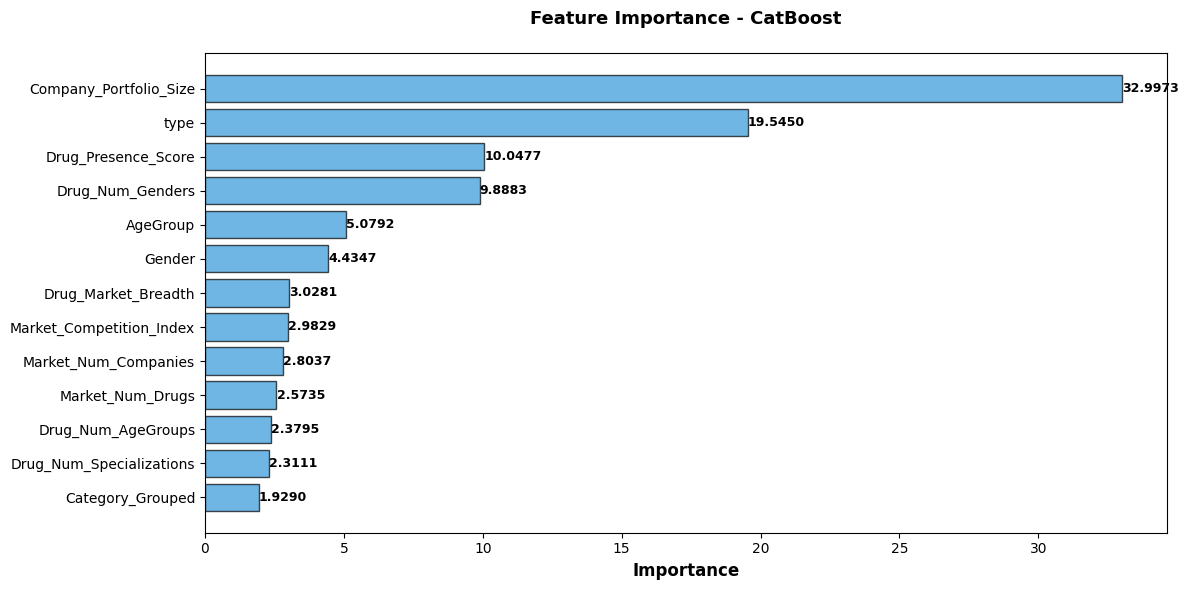

In [47]:
best_model = fitted_models[best_model_name]

if hasattr(best_model, 'feature_importances_'):

    feature_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(feature_imp.to_string(index=False))

    plt.figure(figsize=(12, 6))

    bars = plt.barh(range(len(feature_imp)), feature_imp['Importance'],
                    color='#3498db', alpha=0.7, edgecolor='black')
    plt.yticks(range(len(feature_imp)), feature_imp['Feature'], fontsize=10)
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Feature Importance - {best_model_name}\n',
             fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()

    for i, (idx, row) in enumerate(feature_imp.iterrows()):
        plt.text(row['Importance'] + 0.005, i, f"{row['Importance']:.4f}",
                va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()